In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/diabetes_binary_health_indicators_BRFSS2015.csv')
print(df.shape)
df.head()

(253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [2]:
print(df.info())
print("\n")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [3]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


Diabetes cases:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64


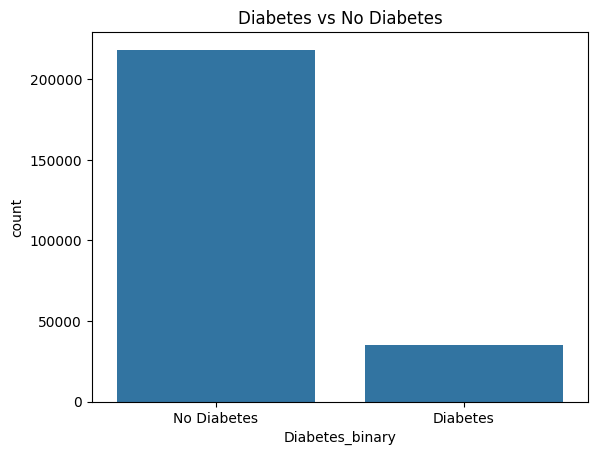

In [4]:
print("Diabetes cases:")
print(df['Diabetes_binary'].value_counts())

sns.countplot(x='Diabetes_binary', data=df)
plt.title('Diabetes vs No Diabetes')
plt.xticks([0,1], ['No Diabetes', 'Diabetes'])
plt.show()

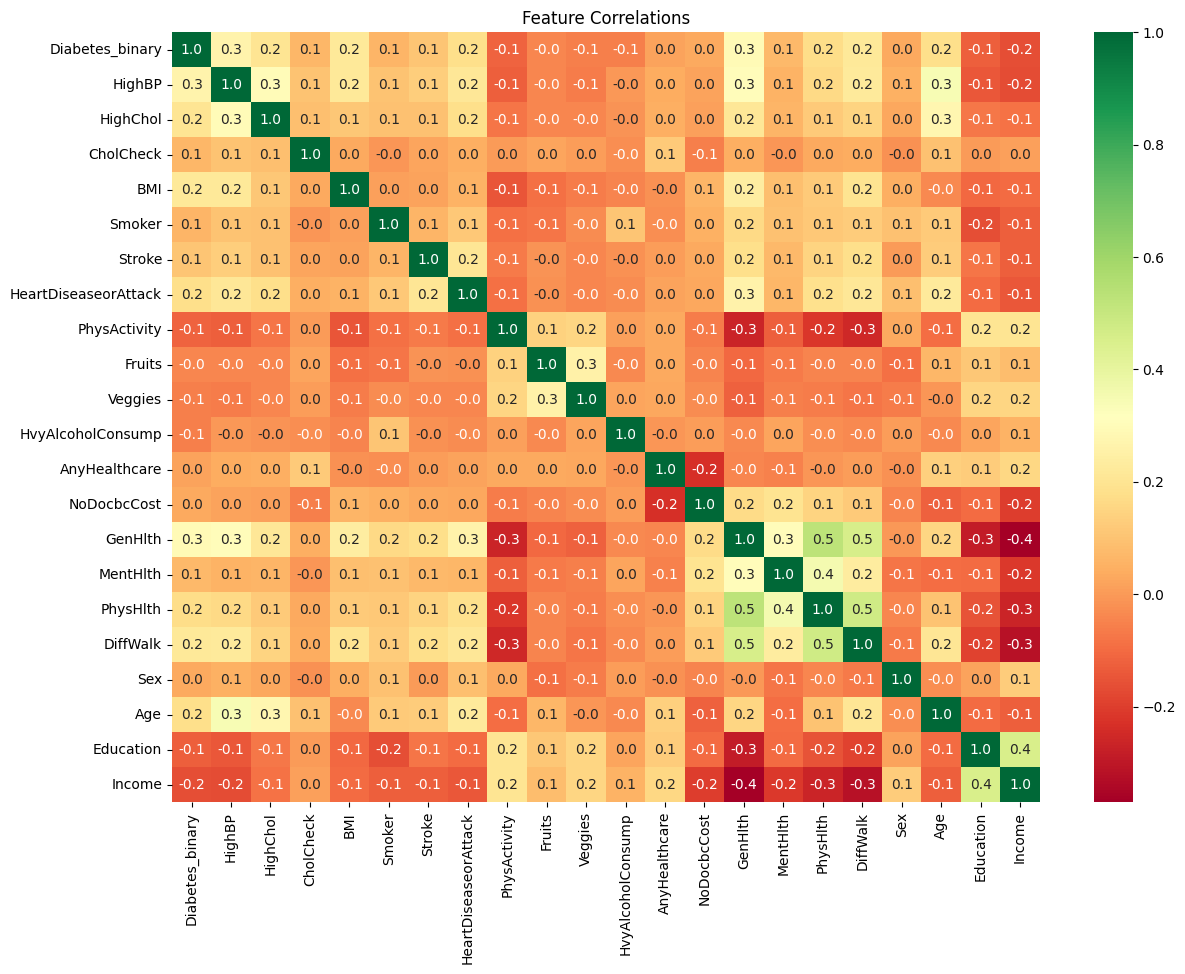

In [5]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, fmt='.1f', cmap='RdYlGn')
plt.title('Feature Correlations')
plt.show()

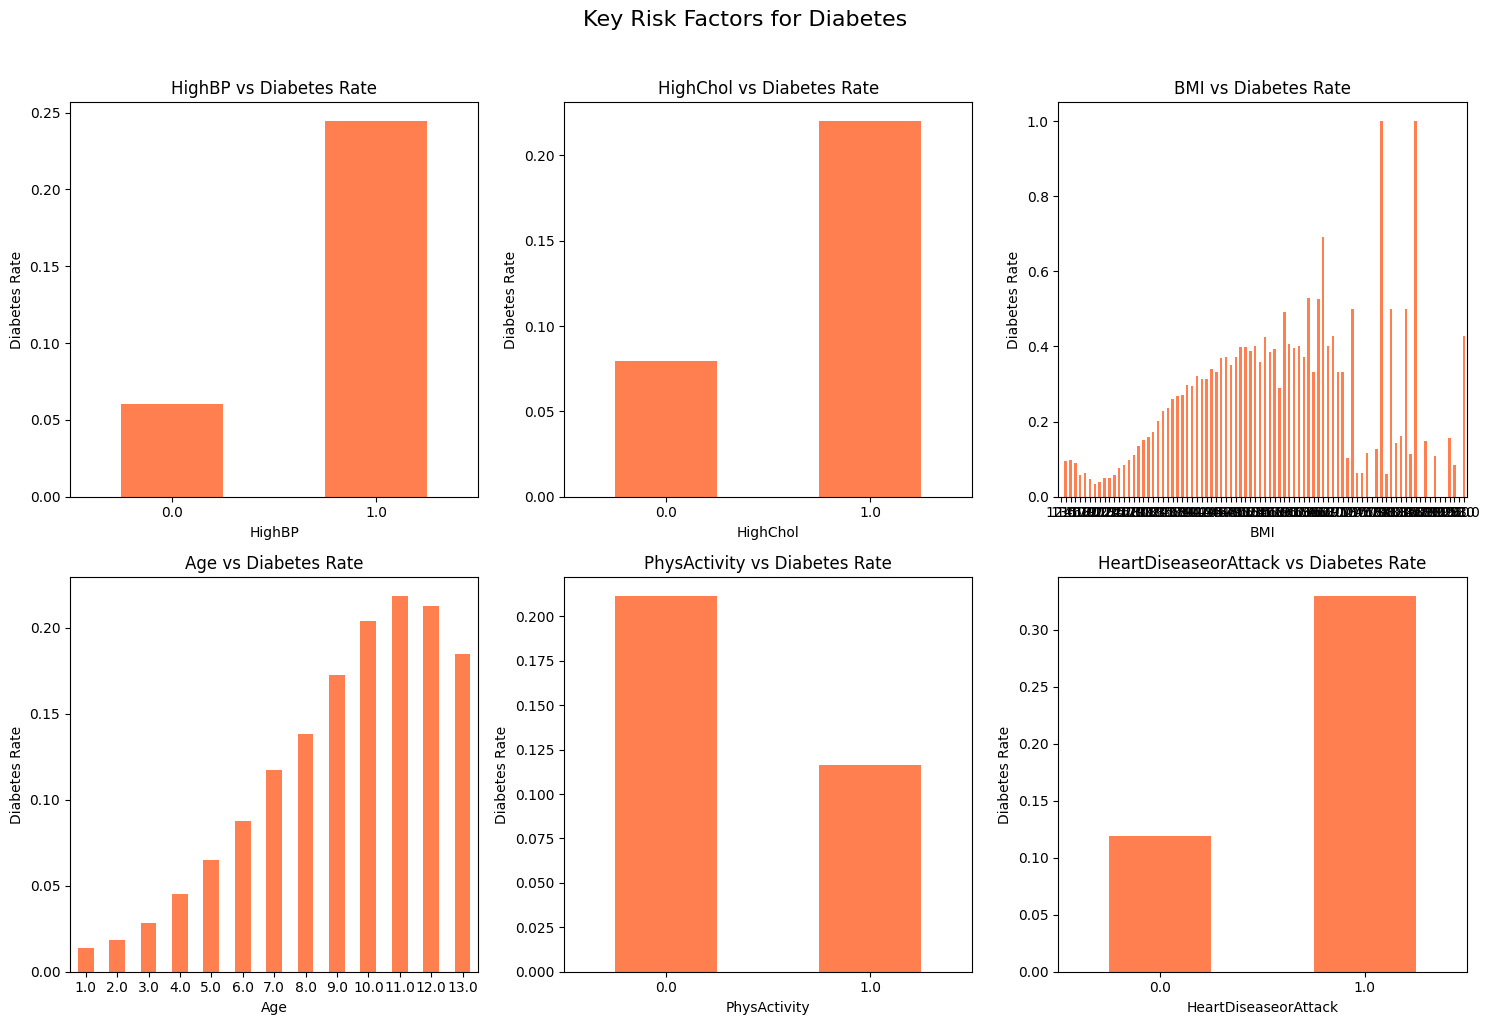

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

features = ['HighBP', 'HighChol', 'BMI', 'Age', 'PhysActivity', 'HeartDiseaseorAttack']

for i, col in enumerate(features):
    ax = axes[i//3, i%3]
    df.groupby(col)['Diabetes_binary'].mean().plot(kind='bar', ax=ax, color='coral')
    ax.set_title(f'{col} vs Diabetes Rate')
    ax.set_ylabel('Diabetes Rate')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Key Risk Factors for Diabetes', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

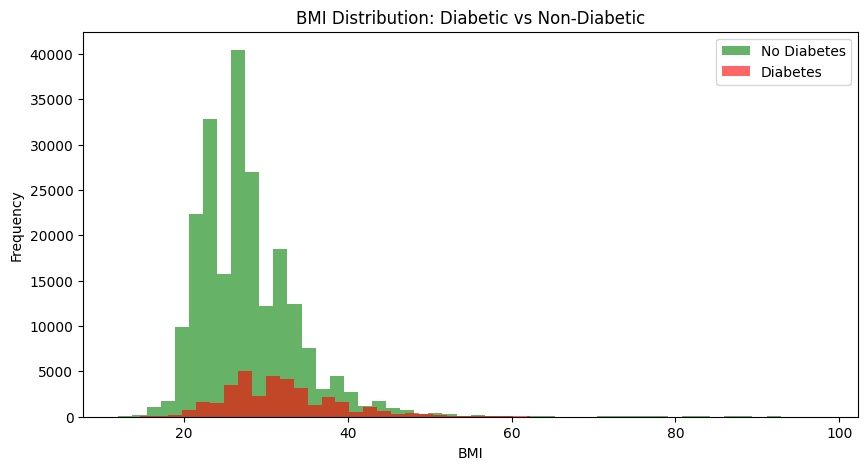

In [7]:
plt.figure(figsize=(10,5))
df[df['Diabetes_binary']==0]['BMI'].plot(kind='hist', alpha=0.6, bins=50, label='No Diabetes', color='green')
df[df['Diabetes_binary']==1]['BMI'].plot(kind='hist', alpha=0.6, bins=50, label='Diabetes', color='red')
plt.title('BMI Distribution: Diabetic vs Non-Diabetic')
plt.xlabel('BMI')
plt.legend()
plt.show()